#  Heart Disease Prediction - Model Training & MLflow Tracking

**Author:** Pronab Sardar  

## Objectives
1. Load preprocessed dataset
2. Apply feature engineering pipeline
3. Train 3 classification models (Logistic Regression, Random Forest, XGBoost)
4. Perform hyperparameter tuning with GridSearchCV
5. Evaluate using multiple metrics + cross-validation
6. Track all experiments in MLflow
7. Register best model to MLflow Model Registry
8. Save best model for deployment

## 1. Import Libraries

In [8]:
%pip install mlflow==2.22.2

   ---------------------------------------- 0.0/29.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/29.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/29.0 MB ? eta -:--:--
   - -------------------------------------- 0.8/29.0 MB 2.3 MB/s eta 0:00:13
   - -------------------------------------- 1.3/29.0 MB 2.3 MB/s eta 0:00:13
   - -------------------------------------- 1.3/29.0 MB 2.3 MB/s eta 0:00:13
   -- ------------------------------------- 1.6/29.0 MB 1.7 MB/s eta 0:00:17
   -- ------------------------------------- 1.8/29.0 MB 1.6 MB/s eta 0:00:18
   --- ------------------------------------ 2.6/29.0 MB 1.9 MB/s eta 0:00:14
   ---- ----------------------------------- 3.1/29.0 MB 2.0 MB/s eta 0:00:13
   ----- ---------------------------------- 3.9/29.0 MB 2.2 MB/s eta 0:00:12
   ------ --------------------------------- 4.7/29.0 MB 2.3 MB/s eta 0:00:11
   ------- -------------------------------- 5.2/29.0 MB 2.4 MB/s eta 0:00:11
   -------- --------

  You can safely remove it manually.


In [4]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 4.9 MB/s eta 0:00:15
    --------------------------------------- 1.6/69.5 MB 4.9 MB/s eta 0:00:14
   - -------------------------------------- 1.8/69.5 MB 4.4 MB/s eta 0:00:16
   - -------------------------------------- 1.8/69.5 MB 4.4 MB/s eta 0:00:16
   - -------------------------------------- 2.4/69.5 MB 2.3 MB/s eta 0:00:30
   - -------------------------------------- 3.1/69.5 MB 2.6 MB/s eta 0:00:26
   -- ------------------------------------- 4.2/69.5 MB 2.9 MB/s eta 0:00:23
   -- ------------------------------------- 5.0/69.5 MB 3.0 MB/s eta 0:00:22
   --- ------------------------------------ 5.8/69.5 MB 3.1 MB/s eta 0:00:21
   --- ------------------------------------ 6.6/69.5 MB 3.2 MB/s eta 0:00:20
   ---- ----------------------------------- 7.3/69.5 MB 3.3 MB/s eta 0:00:19
   ---- -----

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_preprocessing import build_preprocessor, load_and_split

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
PALETTE = ['#2ecc71', '#e74c3c', '#3498db']

print('All libraries loaded successfully!')
print(f'MLflow version: {mlflow.__version__}')

All libraries loaded successfully!
MLflow version: 2.22.2


## 2. Setup MLflow Experiment

In [2]:
# Set MLflow tracking URI (local)
mlflow.set_tracking_uri('file:../mlruns')

# Set experiment name
EXPERIMENT_NAME = 'Heart_Disease_Prediction_Pronab'
mlflow.set_experiment(EXPERIMENT_NAME)

REGISTERED_MODEL_NAME = 'HeartDiseasePredictor_Pronab'

print(f'Experiment: {EXPERIMENT_NAME}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Experiment: Heart_Disease_Prediction_Pronab
Tracking URI: file:../mlruns


## 3. Load & Split Data

In [3]:
# Load and split data using preprocessing module
X_train, X_test, y_train, y_test = load_and_split(csv_path='../data/raw/heart_disease.csv')

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')
print(f'\nTraining class distribution:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nTesting class distribution:')
print(y_test.value_counts(normalize=True).round(3))

Training set shape: (242, 13)
Testing set shape: (61, 13)

Training class distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Testing class distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


In [4]:
# Preview training data
print('First 5 rows of training data:')
X_train.head()

First 5 rows of training data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0
208,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0
167,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0
105,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0


## 4. Build Preprocessing Pipeline

In [5]:
# Build the preprocessing pipeline (includes feature engineering)
preprocessor = build_preprocessor()
print('Preprocessing pipeline built successfully!')
print('\nPipeline steps:')
for name, step in preprocessor.named_steps.items():
    print(f'  - {name}: {type(step).__name__}')

Preprocessing pipeline built successfully!

Pipeline steps:
  - feature_engineer: FeatureEngineer
  - column_transformer: ColumnTransformer


## 5. Define Helper Functions for Plotting

In [6]:
def plot_confusion_matrix_fn(y_true, y_pred, model_name):
    """Generate confusion matrix plot."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    path = f'confusion_matrix_{model_name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=100)
    plt.close()
    return path


def plot_roc_curve_fn(y_true, y_proba, model_name):
    """Generate ROC curve plot."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})', linewidth=2, color='#e74c3c')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    path = f'roc_{model_name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=100)
    plt.close()
    return path


def plot_pr_curve_fn(y_true, y_proba, model_name):
    """Generate Precision-Recall curve plot."""
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, linewidth=2, color='#3498db')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}', fontweight='bold')
    plt.grid(alpha=0.3)
    path = f'pr_curve_{model_name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=100)
    plt.close()
    return path


def save_classification_report_fn(y_true, y_pred, model_name):
    """Save classification report as text file."""
    report = classification_report(y_true, y_pred, target_names=['No Disease', 'Disease'])
    path = f'classification_report_{model_name}.txt'
    with open(path, 'w') as f:
        f.write(f'Classification Report - {model_name}\n')
        f.write('=' * 60 + '\n')
        f.write(report)
    return path


print('Helper functions defined!')

Helper functions defined!


## 6. Define Training Function with MLflow Tracking

In [7]:
def train_and_log(model, param_grid, model_name, X_train, X_test, y_train, y_test, preprocessor):
    """Train a model with GridSearchCV and log everything to MLflow."""
    with mlflow.start_run(run_name=model_name) as run:
        # Build complete pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        # Stratified K-Fold for cross-validation
        cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Hyperparameter tuning
        print(f'Tuning hyperparameters for {model_name}...')
        grid = GridSearchCV(
            pipeline, param_grid,
            cv=cv_strategy,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        
        # Predictions
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]
        
        # Cross-validation scores on training set
        cv_scores = cross_val_score(
            best_model, X_train, y_train,
            cv=cv_strategy, scoring='roc_auc'
        )
        
        # Compute metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'cv_roc_auc_mean': cv_scores.mean(),
            'cv_roc_auc_std': cv_scores.std(),
        }
        
        # Log parameters
        mlflow.log_params(grid.best_params_)
        mlflow.log_param('cv_folds', 5)
        mlflow.log_param('test_size', 0.2)
        mlflow.log_param('model_type', model_name)
        
        # Log metrics
        mlflow.log_metrics(metrics)
        
        # Log tags
        mlflow.set_tag('author', 'Pronab Sardar')
        mlflow.set_tag('dataset', 'UCI Heart Disease')
        mlflow.set_tag('stage', 'development')
        mlflow.set_tag('notebook', '02_Model_Training.ipynb')
        
        # Generate & log artifacts (plots)
        cm_path = plot_confusion_matrix_fn(y_test, y_pred, model_name)
        roc_path = plot_roc_curve_fn(y_test, y_proba, model_name)
        pr_path = plot_pr_curve_fn(y_test, y_proba, model_name)
        report_path = save_classification_report_fn(y_test, y_pred, model_name)
        
        mlflow.log_artifact(cm_path)
        mlflow.log_artifact(roc_path)
        mlflow.log_artifact(pr_path)
        mlflow.log_artifact(report_path)
        
        # Clean up local files
        for p in [cm_path, roc_path, pr_path, report_path]:
            if os.path.exists(p):
                os.remove(p)
        
        # Log model with signature and input example
        signature = infer_signature(X_train, best_model.predict(X_train))
        mlflow.sklearn.log_model(
            sk_model=best_model,
            artifact_path='model',
            signature=signature,
            input_example=X_train.head(3),
            registered_model_name=f'{REGISTERED_MODEL_NAME}_{model_name}'
        )
        
        # Print summary
        print(f'\n{"="*60}')
        print(f'MODEL: {model_name}')
        print(f'{"="*60}')
        print(f'Best params: {grid.best_params_}')
        print(f'CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
        print(f'\nTest Metrics:')
        for k, v in metrics.items():
            print(f'  {k}: {v:.4f}')
        print(f'\nRun ID: {run.info.run_id}')
        
        return best_model, metrics, run.info.run_id


print('Training function defined!')

Training function defined!


## 7. Define Models & Hyperparameter Grids

In [8]:
# Define models with their hyperparameter grids
models_config = {
    'LogisticRegression': (
        LogisticRegression(max_iter=2000, random_state=42),
        {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs']
        }
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_split': [2, 5]
        }
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False),
        {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 6],
            'classifier__learning_rate': [0.05, 0.1]
        }
    ),
}

print(f'Models to train: {list(models_config.keys())}')
print(f'Total combinations to test: {sum(np.prod([len(v) for v in p.values()]) for _, (_, p) in models_config.items())}')

Models to train: ['LogisticRegression', 'RandomForest', 'XGBoost']
Total combinations to test: 24


## 8. Train All Models

In [9]:
# Train each model and collect results
results = {}

for name, (model, params) in models_config.items():
    best_model, metrics, run_id = train_and_log(
        model, params, name,
        X_train, X_test, y_train, y_test,
        preprocessor
    )
    results[name] = {
        'model': best_model,
        'metrics': metrics,
        'run_id': run_id
    }

print('\n' + '=' * 60)
print('ALL MODELS TRAINED SUCCESSFULLY!')
print('=' * 60)

Tuning hyperparameters for LogisticRegression...


Registered model 'HeartDiseasePredictor_Pronab_LogisticRegression' already exists. Creating a new version of this model...
Created version '3' of model 'HeartDiseasePredictor_Pronab_LogisticRegression'.



MODEL: LogisticRegression
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
CV ROC-AUC: 0.9006 (+/- 0.0217)

Test Metrics:
  accuracy: 0.9016
  precision: 0.8667
  recall: 0.9286
  f1: 0.8966
  roc_auc: 0.9719
  cv_roc_auc_mean: 0.9006
  cv_roc_auc_std: 0.0217

Run ID: c7bd1c473261446daea8868c4648c8eb
Tuning hyperparameters for RandomForest...


Registered model 'HeartDiseasePredictor_Pronab_RandomForest' already exists. Creating a new version of this model...
Created version '3' of model 'HeartDiseasePredictor_Pronab_RandomForest'.



MODEL: RandomForest
Best params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
CV ROC-AUC: 0.8864 (+/- 0.0307)

Test Metrics:
  accuracy: 0.8852
  precision: 0.8387
  recall: 0.9286
  f1: 0.8814
  roc_auc: 0.9524
  cv_roc_auc_mean: 0.8864
  cv_roc_auc_std: 0.0307

Run ID: 5f604857eb3149e78d3a1e8d5c4fb1b8
Tuning hyperparameters for XGBoost...



MODEL: XGBoost
Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
CV ROC-AUC: 0.8726 (+/- 0.0207)

Test Metrics:
  accuracy: 0.9016
  precision: 0.8667
  recall: 0.9286
  f1: 0.8966
  roc_auc: 0.9405
  cv_roc_auc_mean: 0.8726
  cv_roc_auc_std: 0.0207

Run ID: a2bdb6e7398b4bec992cb3972422a8c7

ALL MODELS TRAINED SUCCESSFULLY!


Registered model 'HeartDiseasePredictor_Pronab_XGBoost' already exists. Creating a new version of this model...
Created version '3' of model 'HeartDiseasePredictor_Pronab_XGBoost'.


## 9. Compare Model Performance

In [10]:
# Build comparison DataFrame
comparison_df = pd.DataFrame({name: r['metrics'] for name, r in results.items()}).T
comparison_df = comparison_df.round(4)
print('Model Comparison:')
print('=' * 80)
comparison_df

Model Comparison:


,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean,cv_roc_auc_std
LogisticRegression,0.9016,0.8667,0.9286,0.8966,0.9719,0.9006,0.0217
RandomForest,0.8852,0.8387,0.9286,0.8814,0.9524,0.8864,0.0307
XGBoost,0.9016,0.8667,0.9286,0.8966,0.9405,0.8726,0.0207


In [11]:
# Save comparison to CSV
os.makedirs('../models', exist_ok=True)
comparison_df.to_csv('../models/model_comparison.csv')
print('Comparison saved to ../models/model_comparison.csv')

Comparison saved to ../models/model_comparison.csv


## 10. Visualize Model Comparison

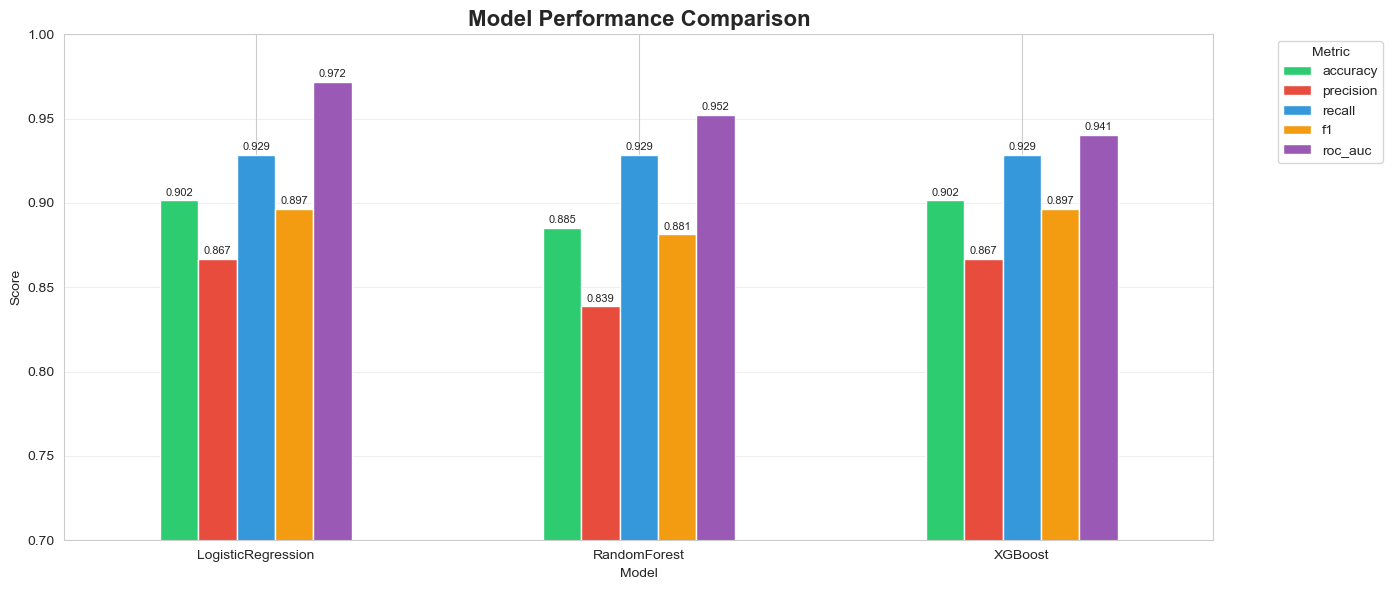

In [12]:
# Bar chart of key metrics
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, ax = plt.subplots(figsize=(14, 6))
comparison_df[metrics_to_plot].plot(kind='bar', ax=ax, color=PALETTE + ['#f39c12', '#9b59b6'])
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0.7, 1.0)
ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('../screenshots/mlflow/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

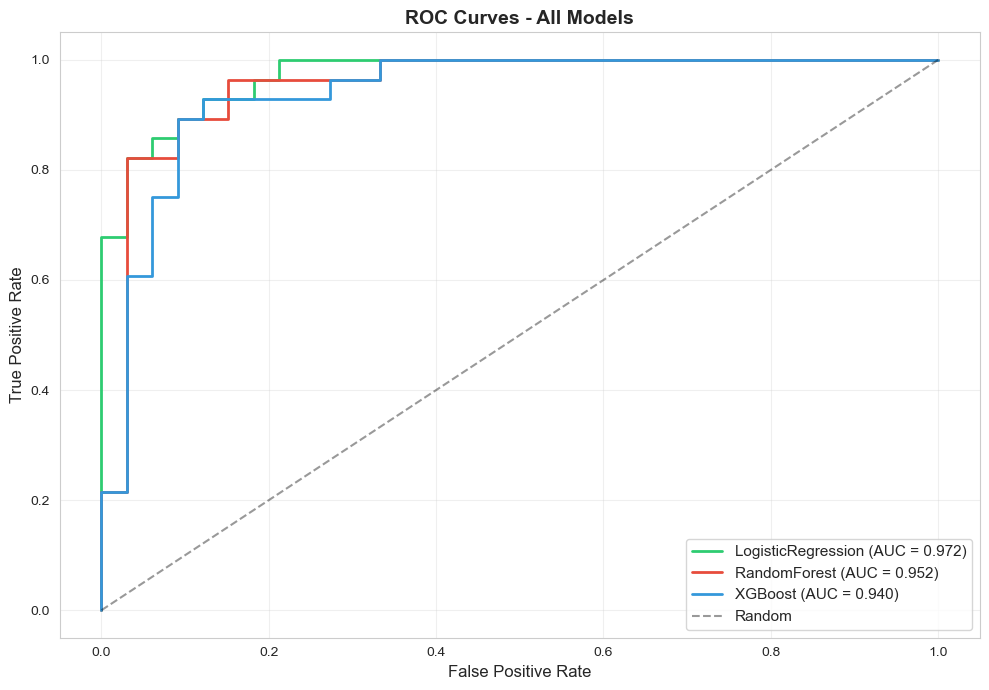

In [13]:
# Combined ROC curves
plt.figure(figsize=(10, 7))
for i, (name, data) in enumerate(results.items()):
    model = data['model']
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=PALETTE[i])

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../screenshots/mlflow/roc_all_models.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Select Best Model

In [14]:
# Select best model based on ROC-AUC
best_name = max(results, key=lambda k: results[k]['metrics']['roc_auc'])
best_model = results[best_name]['model']
best_metrics = results[best_name]['metrics']
best_run_id = results[best_name]['run_id']

print(f'🏆 BEST MODEL: {best_name}')
print(f'   ROC-AUC: {best_metrics["roc_auc"]:.4f}')
print(f'   Accuracy: {best_metrics["accuracy"]:.4f}')
print(f'   F1-score: {best_metrics["f1"]:.4f}')
print(f'   Run ID: {best_run_id}')

🏆 BEST MODEL: LogisticRegression
   ROC-AUC: 0.9719
   Accuracy: 0.9016
   F1-score: 0.8966
   Run ID: c7bd1c473261446daea8868c4648c8eb


## 12. Save Best Model for Deployment

In [15]:
# Save best model as .pkl for API deployment
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
print(f'✅ Best model ({best_name}) saved to ../models/best_model.pkl')

✅ Best model (LogisticRegression) saved to ../models/best_model.pkl


## 13. Promote Best Model to Production Stage

In [22]:
# Register best model in Production stage
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri('file:../mlruns')
client = MlflowClient()
registered_name = f'{REGISTERED_MODEL_NAME}_{best_name}'

try:
    versions = client.search_model_versions(f"name='{registered_name}'")
    if versions:
        latest_version = max(int(v.version) for v in versions)
        client.transition_model_version_stage(
            name=registered_name,
            version=latest_version,
            stage='Production',
            archive_existing_versions=True
        )
        print(f'✅ Model {registered_name} v{latest_version} promoted to PRODUCTION')
    else:
        print('No registered versions found.')
except Exception as e:
    print(f'Registry promotion warning: {e}')

✅ Model HeartDiseasePredictor_Pronab_LogisticRegression v3 promoted to PRODUCTION


## 14. Feature Importance (For Tree-Based Models)

In [23]:
# Plot feature importance for tree-based models
if best_name in ['RandomForest', 'XGBoost']:
    classifier = best_model.named_steps['classifier']
    if hasattr(classifier, 'feature_importances_'):
        # Get feature names from the preprocessor
        try:
            feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
        except Exception:
            feature_names = [f'feature_{i}' for i in range(len(classifier.feature_importances_))]
        
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        
        plt.figure(figsize=(10, 8))
        plt.barh(range(len(indices)), importances[indices], color='#2ecc71')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel('Importance', fontsize=12)
        plt.title(f'Top 15 Feature Importances - {best_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../screenshots/mlflow/feature_importance.png', dpi=100, bbox_inches='tight')
        plt.show()
else:
    print(f'{best_name} does not provide feature_importances_.')

LogisticRegression does not provide feature_importances_.


## 15. Test Prediction with Best Model

In [24]:
# Sample patient data
sample_patient = pd.DataFrame([{
    'age': 55, 'sex': 1, 'cp': 3, 'trestbps': 140, 'chol': 250,
    'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0,
    'oldpeak': 1.5, 'slope': 2, 'ca': 0, 'thal': 2
}])

prediction = best_model.predict(sample_patient)[0]
probability = best_model.predict_proba(sample_patient)[0]

print('Sample Patient Prediction:')
print('=' * 50)
print(f'Input: {sample_patient.iloc[0].to_dict()}')
print(f'\nPrediction: {"High Risk (Disease)" if prediction == 1 else "Low Risk (No Disease)"}')
print(f'Confidence: {probability.max():.2%}')
print(f'\nProbability breakdown:')
print(f'  - No Disease: {probability[0]:.2%}')
print(f'  - Disease:    {probability[1]:.2%}')

Sample Patient Prediction:
Input: {'age': 55.0, 'sex': 1.0, 'cp': 3.0, 'trestbps': 140.0, 'chol': 250.0, 'fbs': 0.0, 'restecg': 1.0, 'thalach': 150.0, 'exang': 0.0, 'oldpeak': 1.5, 'slope': 2.0, 'ca': 0.0, 'thal': 2.0}

Prediction: Low Risk (No Disease)
Confidence: 63.08%

Probability breakdown:
  - No Disease: 63.08%
  - Disease:    36.92%


## 🎯 Summary & Next Steps

### What We Accomplished
 Loaded and split the Heart Disease UCI dataset  
 Built a comprehensive preprocessing pipeline with feature engineering  
 Trained 3 models: Logistic Regression, Random Forest, XGBoost  
 Performed hyperparameter tuning with GridSearchCV (5-fold CV)  
 Tracked all experiments with MLflow (params, metrics, artifacts, plots)  
 Registered models in MLflow Model Registry  
 Promoted best model to Production stage  
 Saved best model as pickle for API deployment  

### View Results in MLflow UI
Run in terminal:
```bash
mlflow ui
```
Then open: http://localhost:5000

### Next Steps
1. **Deploy** the model via FastAPI (`src/api.py`)
2. **Containerize** with Docker
3. **Test** the API endpoints via Swagger UI
4. **Push** to GitHub to trigger CI/CD
5. **Deploy** to Kubernetes via Helm chart
6. **Monitor** via Prometheus + Grafana

### Repository & Report
- **GitHub:** https://github.com/pronabsardar/heart-disease-mlops-pronab
- **Report:** `report/final_report.md`

---